# Chest X-Ray Pneumonia Classification With Deep Learning
---
## Objective
The objective of this project is to build a Deep Learning model using PyTorch to automatically detect the presence of pneumonia from pediatric chest X-ray images. This is a critical medical imaging task where the goal is to assist radiologists by accurately triaging patients and minimizing false negatives (ensuring no sick patient is sent home without treatment).

## Project Goals:
- **Task:** Binary Classification (Normal vs. Pneumonia).
- **Model Type:** Convolutional Neural Network (CNN) using Transfer Learning (ResNet-18 architecture).
- **Success Metric:** Maximize **Recall (Sensitivity)** to prevent misdiagnosing sick patients, while monitoring Precision to control false alarms.
- **Approach:** - Leverage pre-trained weights from `torchvision.models`.
  - Replace the classification head with a single-neuron output.
  - Implement robust Data Augmentation using `torchvision.transforms.v2`.
  - Optimize the network using `BCEWithLogitsLoss` for numerical stability and `AdamW` with early stopping.

## Dataset Description:
This project utilizes the well-known "Chest X-Ray Images (Pneumonia)" dataset from Kaggle, containing 5,856 verified X-ray images collected from pediatric patients.

### Input Features:
The model processes raw X-ray images through a rigorous preprocessing pipeline:
- **Spatial Transformation:** Images are cropped and resized to 224x224 pixels to match the ResNet input requirements.
- **Data Augmentation:** Random rotations and resized crops are applied to the training set to prevent overfitting and force the model to learn anatomical patterns rather than specific image framing.
- **Normalization:** Pixel intensities are rescaled and normalized using standard ImageNet channel statistics (Mean: [0.485, 0.456, 0.406], Std: [0.229, 0.224, 0.225]).

### Target Classes:
The dataset is heavily imbalanced and divided into 2 distinct categories:
- **0:** Normal (Healthy lungs)
- **1:** Pneumonia (Presence of viral or bacterial opacity)


# 🛠️ 1. Setup & Environment
---


In [25]:
!pip install optuna torchmetrics

In [26]:
# Standard Library & Utilities
import os
import kagglehub

# Data Manipulation & Analysis
import numpy as np
import pandas as pd
import sklearn

# PyTorch Framework
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# Computer Vision & Image Processing
import torchvision
from torchvision import datasets
import torchvision.transforms.v2 as T
from torchvision.utils import make_grid
from PIL import Image

# Visualization
import matplotlib.pyplot as plt

# Metrics
import torchmetrics

In [27]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using device: {device}")

Using device: cuda


# 📂 2. Image Data Loading & Exploration
---

### 2.1 Data Loading


In [28]:
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.


In [29]:
base_dir = os.path.join(path, "chest_xray")
train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

### 2.2 Visualising a sample from the training Dataset



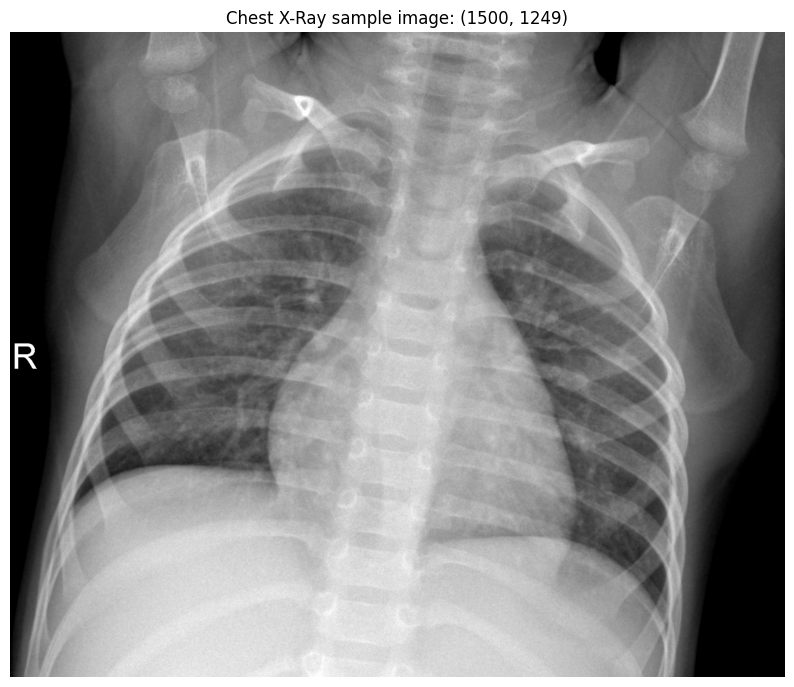

In [30]:
normal_dir = os.path.join(path, "chest_xray", "train", "NORMAL")


samp_img = os.listdir(normal_dir)[7]
img_path = os.path.join(normal_dir, samp_img)

img = Image.open(img_path)

plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.title(f"Chest X-Ray sample image: {img.size}")
plt.axis('off')
plt.show()


Different images are in different dimensions, so our objective is to re-scale them and resize making all of them equal.

### 2.3 Preprocessing


In [31]:
val_test_transforms = T.Compose([
    T.Resize((224, 224)),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_transforms = T.Compose([
    T.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    T.RandomRotation(degrees=15),
    T.ToImage(),
    T.ToDtype(torch.float32, scale=True),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [32]:
weights = torchvision.models.ResNet18_Weights.IMAGENET1K_V1
transforms = weights.transforms()
train_set = datasets.ImageFolder(train_dir, transform=transforms)
val_set = datasets.ImageFolder(val_dir, transform=transforms)
test_set = datasets.ImageFolder(test_dir, transform=transforms)

### 2.4 Batching

In [33]:
batch_size = 32
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

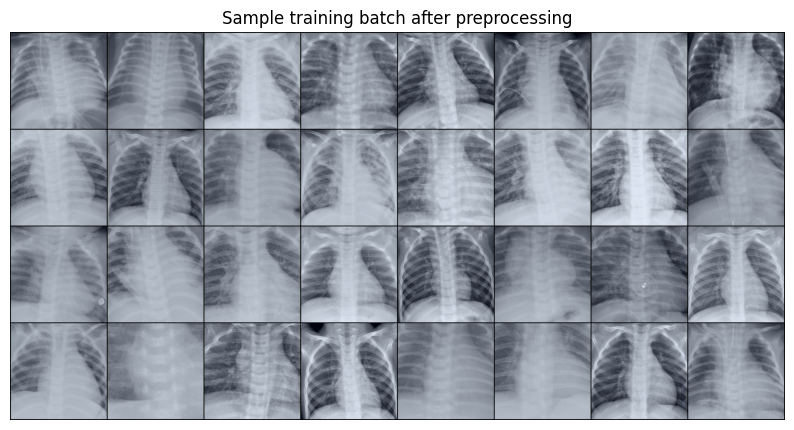

In [34]:
imgs, labels = next(iter(train_loader))

grid = make_grid(imgs[:32], nrow=8, normalize=True)

grid_permuted= grid.permute(1, 2, 0)

plt.figure(figsize=(10, 16))
plt.imshow(grid_permuted)
plt.axis('off')
plt.title("Sample training batch after preprocessing")
plt.show()


# 🏗️ 3. Model Architecture
---


In [35]:
model = torchvision.models.resnet18(weights=weights)
for param in model.parameters():
  param.requires_grad = False

model.fc = torch.nn.Linear(model.fc.in_features, 1)
model.to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

# ⚙️ 4. Training Configuration
---

In [36]:
def evaluate_tm(model, data_loader, metric):
    model.eval()
    metric.reset()
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.float().unsqueeze(1).to(device)
            y_pred = model(X_batch)
            metric.update(y_pred, y_batch)
    return metric.compute()

In [37]:
def train_es_MAX(model, optimizer, criterion, metric, train_loader, valid_loader,
               n_epochs,patience = 5,scheduler=None):
  history = {"train_losses": [], "train_metrics": [], "valid_metrics": []}

  stress = 0
  best_valid_metric = 0
  for epoch in range(n_epochs):
    total_loss = 0
    metric.reset()
    model.train()
    for X_batch, y_batch in train_loader:
      optimizer.zero_grad()
      X_batch, y_batch = X_batch.to(device), y_batch.float().unsqueeze(1).to(device)
      y_pred = model(X_batch)
      loss = criterion(y_pred, y_batch)
      total_loss += loss.item()

      loss.backward()
      optimizer.step()
      metric.update(y_pred, y_batch)

    mean_loss = total_loss / len(train_loader)
    train_metric = metric.compute().item()
    history["train_losses"].append(mean_loss)
    history["train_metrics"].append(train_metric)

    current_valid_metric = evaluate_tm(model, valid_loader, metric).item()
    history["valid_metrics"].append(current_valid_metric)
    print(f"Epoch {epoch + 1}/{n_epochs}, "
              f"train loss: {history['train_losses'][-1]:.4f}, "
              f"train metric: {history['train_metrics'][-1]:.4f}, "
              f"valid metric: {history['valid_metrics'][-1]:.4f}")
    if scheduler:
      scheduler.step(current_valid_metric)
    if current_valid_metric > best_valid_metric:
      best_valid_metric = current_valid_metric
      stress = 0
      torch.save(model.state_dict(), 'best_model.pth')
    else:

      stress += 1
      if stress == patience:
        print(f"\n Early stopping triggered ")
        model.load_state_dict(torch.load('best_model.pth'))
        break
  return history

# 🚀 5. Model Training
---

In [38]:
optimizer = torch.optim.AdamW(model.fc.parameters(), lr=5e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.2, patience=5)
criterion = nn.BCEWithLogitsLoss()
metric = torchmetrics.Recall(task="binary").to(device)

history = train_es_MAX(model,optimizer,criterion,metric,train_loader,valid_loader,100,patience =26,scheduler = scheduler)

Epoch 1/100, train loss: 0.3596, train metric: 0.9822, valid metric: 1.0000
Epoch 2/100, train loss: 0.2073, train metric: 0.9670, valid metric: 1.0000
Epoch 3/100, train loss: 0.1711, train metric: 0.9695, valid metric: 1.0000
Epoch 4/100, train loss: 0.1541, train metric: 0.9693, valid metric: 1.0000
Epoch 5/100, train loss: 0.1446, train metric: 0.9659, valid metric: 1.0000
Epoch 6/100, train loss: 0.1390, train metric: 0.9683, valid metric: 1.0000
Epoch 7/100, train loss: 0.1365, train metric: 0.9690, valid metric: 1.0000
Epoch 8/100, train loss: 0.1298, train metric: 0.9708, valid metric: 1.0000
Epoch 9/100, train loss: 0.1297, train metric: 0.9726, valid metric: 1.0000
Epoch 10/100, train loss: 0.1263, train metric: 0.9737, valid metric: 1.0000
Epoch 11/100, train loss: 0.1273, train metric: 0.9711, valid metric: 1.0000
Epoch 12/100, train loss: 0.1290, train metric: 0.9729, valid metric: 1.0000
Epoch 13/100, train loss: 0.1285, train metric: 0.9703, valid metric: 1.0000
Epoch 14

# 📉 6. Evaluation & Learning Curves
---

In [39]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

test_recall = torchmetrics.Recall(task="binary").to(device)
test_precision = torchmetrics.Precision(task="binary").to(device)
test_precision.reset()
test_recall.reset()


with torch.no_grad():
  for X_test, y_test in test_loader:
    X_test, y_test = X_test.to(device), y_test.float().unsqueeze(1).to(device)

    y_pred = model(X_test)
    test_recall.update(y_pred, y_test)
    test_precision.update(y_pred, y_test)

test_rcll = test_recall.compute().item()
test_prec = test_precision.compute().item()

print(f"\n{'='*40}")
print(f"Recall: {test_rcll:.2%}",f"Precision: {test_prec:.2%}")
print(f"{'='*40}")


Recall: 98.46% Precision: 73.42%


# Conclusion & Key Insights
---
### Final Performance Metrics
After evaluating the model on the unseen Test Set (624 images), the network achieved the following results:
- **Recall (Sensitivity):** 98.46%
- **Precision:** 73.42%

### Clinical Interpretation: The "Safe Screening" Trade-off
The model successfully met its primary objective as a first-line diagnostic tool. A Recall of nearly 98.5% proves the network is highly capable of identifying sick patients, keeping dangerous False Negatives to an absolute minimum.

The Precision of 73.4% highlights a predictable consequence of the imbalanced training dataset: a higher rate of False Positives. The model leans towards a conservative approach—when in doubt, it flags the X-ray as positive. In real-world medical triage, this is exactly the desired behavior, as it is infinitely safer to send a healthy patient for a secondary manual review than to dismiss a patient with pneumonia.

### Experimental Findings: The Data Augmentation Paradox
During the optimization phase, two distinct preprocessing pipelines were tested:
1. **Pre-trained Default Transforms:** Utilizing the standard resizing, cropping, and normalization expected by the default `torchvision` ResNet-18 weights.
2. **Custom Data Augmentation:** Applying dynamic techniques such as random rotations, resized crops, and horizontal flips to artificially expand the training distribution.

**Key Insight:** Interestingly, the application of custom Data Augmentation **did not** improve the final performance. In fact, relying strictly on the model's default transformations yielded the most stable and accurate metrics. This suggests that for highly standardized medical images like chest X-rays—where anatomical positioning is strict and consistent—introducing geometric distortions (like random rotations) introduces unnecessary noise and may destroy critical structural context rather than aiding generalization.